## Testing GPUs

In [3]:
import torch
import tensorflow as tf

print("PyTorch MPS (GPU) available:", torch.backends.mps.is_available())
print("TensorFlow Version:", tf.__version__)
print("TensorFlow running on CPU:", len(tf.config.list_physical_devices('CPU')) > 0)

PyTorch MPS (GPU) available: True
TensorFlow Version: 2.21.0
TensorFlow running on CPU: True


In [4]:
tf.config.list_physical_devices('CPU')

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

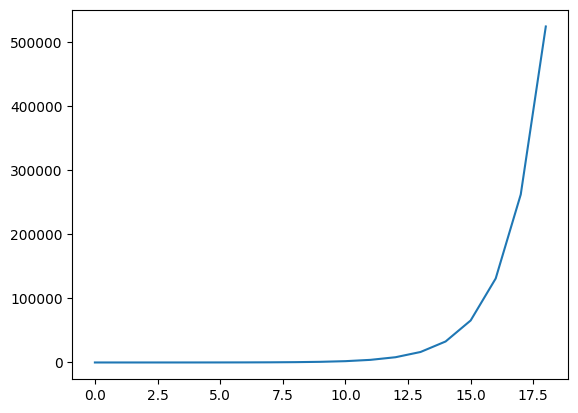

In [5]:
def compute_scaling(base, max_power):
    powers = []
    for i in range(1, max_power):
        powers.append(base ** i)
    return powers
powers = compute_scaling(2, 20)

import matplotlib.pyplot as plt
plt.plot(powers)


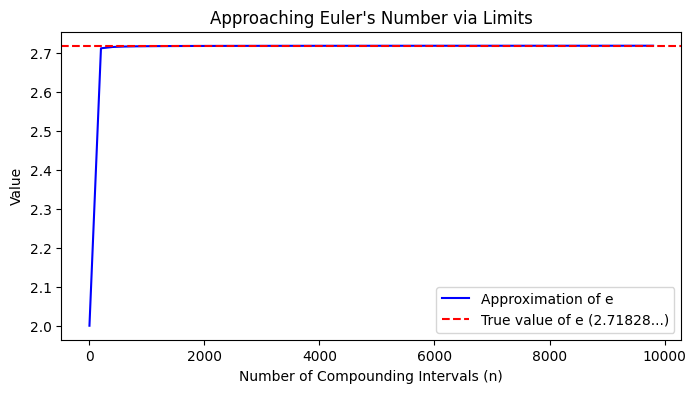

Final approximation of e at n=10000: 2.718143167730419


In [6]:
import matplotlib.pyplot as plt

def calculate_e_limit(max_n):
    # We will track the number of intervals (n) and the resulting value
    n_values = []
    e_approximations = []
    
    # We test larger and larger values of n (compounding more frequently)
    for n in range(1, max_n, max_n // 50):  # stepping through 50 points
        # The limit definition formula for e: (1 + 1/n)^n
        val = (1 + 1/n)**n 
        
        n_values.append(n)
        e_approximations.append(val)
        
    return n_values, e_approximations

# Calculate the limit as n approaches 10,000 intervals
n_vals, e_vals = calculate_e_limit(10000)

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(n_vals, e_vals, label="Approximation of e", color='blue')
plt.axhline(y=2.71828, color='red', linestyle='--', label="True value of e (2.71828...)")
plt.xlabel("Number of Compounding Intervals (n)")
plt.ylabel("Value")
plt.title("Approaching Euler's Number via Limits")
plt.legend()
plt.show()

# Print the final value
print(f"Final approximation of e at n=10000: {e_vals[-1]}")